<a href="https://colab.research.google.com/github/imranasalisu1/Hendeb_project/blob/main/Module3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MODULE 3**

**DATA ACQUISITION AND CURATION FOR ACTIVITY, PROPERTY AND TOXICITY**



---
This module focuses on sourcing high-quality datasets for modeling biological
activity, physicochemical properties, and toxicity. It introduces major public chemical
databases and teaches how to retrieve and format data. Participants learn how to
handle inconsistencies in datasets. Data cleaning and preparation are emphasized as
critical steps. The module ensures datasets are ready for machine learning
applications.

---
**Hands-on Activity**

1. Visit PubChem → search for compounds (e.g., antibacterial agents) → download
  CSV/SDF
 Go to https://pubchem.ncbi.nlm.nih.gov/

2. Visit ChEMBL → download bioactivity data (IC50, Ki)
Go to https://www.ebi.ac.uk/chembl/
Type your protein name in the search bar (e.g., Plasmodium PfDHFR, dengue protease, EGFR kinase, HIV protease)

   i. Click the Targets tab

   ii. Find the target that matches yours and copy the CHEMBL_______ code

   **Tip:** Prefer targets of type SINGLE PROTEIN over ORGANISM — they contain more specific, higher-confidence bioactivity data.

3. Visit EPA CompTox Dashboard → download toxicity datasets
Go to https://comptox.epa.gov/dashboard/downloads

**ChEMBL Dataset Download & Curation**

Why data curation matters?

- ChEMBL aggregates bioactivity data from thousands of publications. This means:
- The same compound may have been tested in multiple labs under different conditions

- Values with > or < relations (e.g., IC50 > 100 µM) are censored data — upper/lower bounds, not true measurements

- Some SMILES strings may be invalid or contain salts that need to be removed.

 - The curation pipeline below addresses all of these issues systematically.

- Losing molecules in this step is expected and necessary — a smaller, high-quality dataset produces better models than a larger, noisy one.

---
**Part 1: Data Collection & Curation**

First we need to connect Google Colab with our Google Drive, so that we can have access to our Google drive within Colab.

This allows us to:

- Save datasets
- Reload data across sessions
- Organize project files


In [2]:
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


**Now create "data" folder in our "Colab Notebooks" folder on Google Drive.**

In [3]:
! mkdir "/content/gdrive/My Drive/Colab Notebooks/data"

mkdir: cannot create directory ‘/content/gdrive/My Drive/Colab Notebooks/data’: File exists


**Install and Import Required Libraries**

We install the ChEMBL web service package so that we can retrieve bioactivity data

In [4]:
!pip install chembl_webresource_client


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.9 MB/s eta 0:00:00


**Import Libraries**

- pandas for data handling
- new_client from chembl for accessing the database

In [5]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

**Step 1: Search for Traget Protein**

Target Identification (Plasmodium PfDHFR)

In [6]:
target = new_client.target
target_query = target.search("Plasmodium PfDHFR")
targets = pd.DataFrame.from_dict(target_query)
targets.head()

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Plasmodium,Plasmodium,16.0,False,CHEMBL4888483,[],ORGANISM,5820
1,[],Plasmodium falciparum,Plasmodium falciparum,13.0,False,CHEMBL364,[],ORGANISM,5833
2,[],Plasmodium berghei,Plasmodium berghei,13.0,False,CHEMBL612653,[],ORGANISM,5821
3,[],Plasmodium yoelii,Plasmodium yoelii,13.0,False,CHEMBL612889,[],ORGANISM,5861
4,[],Plasmodium cynomolgi,Plasmodium cynomolgi,13.0,False,CHEMBL613883,[],ORGANISM,5827


**Reterive Bioactivity data for selected target**

In [7]:
selected_target = targets.target_chembl_id[1]
selected_target

'CHEMBL364'

Now retrieve only bioactivity data for target; Plasmodium falciparum(CHEMBL364) with reported IC50 values in nM (nanomolar) unit.

In [9]:
activity = new_client.activity
results = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")

In [10]:
import pandas as pd
from tqdm.auto import tqdm

# 1. Define the specific columns (using ChEMBL internal names)
# 'canonical_smiles' is the API equivalent for 'Smiles'
selected_columns = [
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
    'pchembl_value'
]

# 2. Setup the filtered query with the .only() constraint
# This prevents the API from sending unnecessary metadata for 58k rows
query = activity.filter(target_chembl_id=selected_target) \
                .filter(standard_type="IC50") \
                .only(selected_columns)

# 3. Fetch data into a list using a progress bar
print(f"Starting download of {len(query)} records...")
results_list = [row for row in tqdm(query, total=len(query), desc="ChEMBL Download")]

# 4. Create the DataFrame
df1 = pd.DataFrame(results_list)

# 5. Rename 'canonical_smiles' to 'Smiles' to match your preference
if 'canonical_smiles' in df1.columns:
    df1 = df1.rename(columns={'canonical_smiles': 'Smiles'})

# Display the first few rows
print("\nDownload Complete!")
print(df1.head())

Starting download of 58588 records...


ChEMBL Download:   0%|          | 0/58588 [00:00<?, ?it/s]


Download Complete!
                                              Smiles molecule_chembl_id  \
0                                               None        CHEMBL76383   
1  C[C@H]1[C@@H](OCCC2ON2C(=O)c2ccccc2O)O[C@@H]2O...        CHEMBL77052   
2                                               None       CHEMBL312787   
3                                               None        CHEMBL74819   
4                                      Oc1cccc(O)c1O       CHEMBL307145   

  pchembl_value standard_units standard_value units       value  
0          4.13             nM        73500.0    uM        73.5  
1          8.37             nM           4.25    nM        4.25  
2          4.65             nM        22500.0    uM        22.5  
3          None             nM       200000.0    uM       200.0  
4          5.25             nM         5660.0     M  0.00000566  


In [11]:
df1.standard_value.unique()

array(['73500.0', '4.25', '22500.0', ..., '4187.0', '7219.0', '2379.0'],
      dtype=object)

In [12]:
print(df1.columns)

Index(['Smiles', 'molecule_chembl_id', 'pchembl_value', 'standard_units',
       'standard_value', 'units', 'value'],
      dtype='object')


**Finally Save the resulting bioactivity data to a CSV file bioactivity_raw_data.csv.**

In [13]:
df1.to_csv('bioactivity_raw_data.csv', index=False)

**Now copy "bioactivity_raw_data.csv" file to Google Drive, in foler "data"**

In [14]:
! cp bioactivity_raw_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"

In [15]:
! ls -l "/content/gdrive/My Drive/Colab Notebooks/data"

total 5324
-rw------- 1 root root 5450771 Apr 23 23:08 bioactivity_raw_data.csv


**Step 3: Bioactivity Data Retrieval (IC50)**

- Retrieve bioactivity data (IC50) for the selected target.

- Inspect Missing Values

In [18]:
df1["standard_value"].isna().sum()

np.int64(2047)

**Filtering Rows with Valid Bioactivity Values**

In [20]:
df2 = df1[df1["standard_value"].notna()]
df2.head(10)

,Smiles,molecule_chembl_id,pchembl_value,standard_units,standard_value,units,value
0,None,CHEMBL76383,4.13,nM,73500.0,uM,73.5
1,C[C@H]1[C@@H](OCCC2ON2C(=O)c2ccccc2O)O[C@@H]2O...,CHEMBL77052,8.37,nM,4.25,nM,4.25
2,None,CHEMBL312787,4.65,nM,22500.0,uM,22.5
3,None,CHEMBL74819,None,nM,200000.0,uM,200.0
4,Oc1cccc(O)c1O,CHEMBL307145,5.25,nM,5660.0,M,0.00000566
5,O=C(NO)c1ccccc1,CHEMBL16300,4.75,nM,17600.0,M,0.0000176
6,None,CHEMBL73969,4.75,nM,18000.0,uM,18.0
7,None,CHEMBL75398,4.44,nM,36200.0,uM,36.2
8,None,CHEMBL74634,5.34,nM,4600.0,uM,4.6
9,None,CHEMBL75710,4.50,nM,31500.0,uM,31.5


**Assign Bioactivity Classes Define active, intermediate, and inactive classes based on IC50 values.**

In [21]:
bioactivity_class = []
for value in df2.standard_value:
    value = float(value)
    if value >= 10000:
        bioactivity_class.append("inactive")
    elif value <= 1000:
        bioactivity_class.append("active")
    else:
        bioactivity_class.append("intermediate")

**Extract Relevant Columns**

In [24]:
molecule_ids = df2.molecule_chembl_id.tolist()
Smiles = df2.Smiles.tolist()
standard_values = df2.standard_value.tolist()

In [27]:
data = list(zip(
    molecule_ids,
    Smiles,
    standard_values,
        bioactivity_class,
))

In [29]:
df3 = pd.DataFrame(
    data,
    columns=[
        "molecule_chembl_id",
        "Smiles",
        "standard_value",
        "bioactivity_class",
    ]
)
df3.head()

,molecule_chembl_id,Smiles,standard_value,bioactivity_class
0,CHEMBL76383,None,73500.0,inactive
1,CHEMBL77052,C[C@H]1[C@@H](OCCC2ON2C(=O)c2ccccc2O)O[C@@H]2O...,4.25,active
2,CHEMBL312787,None,22500.0,inactive
3,CHEMBL74819,None,200000.0,inactive
4,CHEMBL307145,Oc1cccc(O)c1O,5660.0,intermediate


**Remove Compounds without Valid SMILES.** Drop rows with **NaN, empty or None SMILES** values.

In [30]:
df3 = df3.dropna(subset=["Smiles"])
df3 = df3[df3["Smiles"].str.lower() != "none"]
df3 = df3[df3["Smiles"].str.strip() != ""]
df3.head()

,molecule_chembl_id,Smiles,standard_value,bioactivity_class
1,CHEMBL77052,C[C@H]1[C@@H](OCCC2ON2C(=O)c2ccccc2O)O[C@@H]2O...,4.25,active
4,CHEMBL307145,Oc1cccc(O)c1O,5660.0,intermediate
5,CHEMBL16300,O=C(NO)c1ccccc1,17600.0,inactive
11,CHEMBL307153,C[C@H]1[C@@H](OCCCOc2coc(CO)cc2=O)O[C@@H]2O[C@...,9.55,active
12,CHEMBL307153,C[C@H]1[C@@H](OCCCOc2coc(CO)cc2=O)O[C@@H]2O[C@...,16.8,active


**Save Preprocessed Bioactivity Data.** Save the cleaned dataset to CSV and copy to Google Drive.

In [31]:
df3.to_csv("bioactivity_preprocessed_data.csv", index=False)

!cp bioactivity_preprocessed_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"
!ls "/content/gdrive/My Drive/Colab Notebooks/data"

bioactivity_preprocessed_data.csv  bioactivity_raw_data.csv


In [32]:
df3.describe()

,molecule_chembl_id,Smiles,standard_value,bioactivity_class
count,56424,56424,56424,56424
unique,27950,27943,10615,3
top,CHEMBL76,CCN(CC)CCCC(C)Nc1ccnc2cc(Cl)ccc12,10000.0,active
freq,1999,1999,2288,32647


**Exploratory Data Analysis**

In QSAR (Quantitative Structure-Activity Relationship) modeling, **Exploratory Data Analysis (EDA)** is the essential preliminary phase where you "interrogate" your chemical dataset to understand its structure, quality, and patterns before building any predictive models.It is the process of using statistical summaries and visualization techniques to identify outliers, detect correlations between chemical descriptors, and ensure that the chemical space of your training set is appropriate for the biological activity you are studying.

**Key Components of EDA in QSAR**

- **Chemical Space Analysis:** Visualizing how diverse your molecules are (often using PCA or t-SNE) to ensure the model isn't biased toward one specific chemical family.

- **Descriptor Selection/Correlation:** Identifying redundant molecular descriptors. If two descriptors (like Molecular Weight and Molar Refractivity) are 99% correlated, keeping both adds noise to the model.

- **Activity Distribution:** Checking if your biological activity data (e.g., $IC_{50}$ values) is normally distributed or heavily skewed, which determines if you need a log transformation (like converting to $pIC_{50}$).

- **Outlier Detection:** Finding "Activity Cliffs"—molecules that are structurally very similar but have vastly different biological activities.

**Import Libraries**

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')

**Import Bioactivity Dataset**

In [34]:
from google.colab import files
uploaded = files.upload()

Saving bioactivity_preprocessed_data.csv to bioactivity_preprocessed_data (1).csv


In [35]:
df4 = pd.read_csv("bioactivity_preprocessed_data.csv")
df4.head(10)

,molecule_chembl_id,Smiles,standard_value,bioactivity_class
0,CHEMBL77052,C[C@H]1[C@@H](OCCC2ON2C(=O)c2ccccc2O)O[C@@H]2O...,4.25,active
1,CHEMBL307145,Oc1cccc(O)c1O,5660.00,intermediate
2,CHEMBL16300,O=C(NO)c1ccccc1,17600.00,inactive
3,CHEMBL307153,C[C@H]1[C@@H](OCCCOc2coc(CO)cc2=O)O[C@@H]2O[C@...,9.55,active
4,CHEMBL307153,C[C@H]1[C@@H](OCCCOc2coc(CO)cc2=O)O[C@@H]2O[C@...,16.80,active
5,CHEMBL339049,CC(C)(C)NCc1cc(Nc2ccnc3cc(Cl)ccc23)cc(-c2ccc(C...,18.00,active
6,CHEMBL339049,CC(C)(C)NCc1cc(Nc2ccnc3cc(Cl)ccc23)cc(-c2ccc(C...,21.00,active
7,CHEMBL316098,CC(C)(C)NCc1cc(Nc2ccnc3cc(Cl)ccc23)ccc1O,1.47,active
8,CHEMBL316098,CC(C)(C)NCc1cc(Nc2ccnc3cc(Cl)ccc23)ccc1O,3.43,active
9,CHEMBL93286,CC(C)(C)NCc1cc(Nc2ccnc3cc(Cl)ccc23)cc(C2CCCCC2...,6.80,active


**Remove NA Values**

In [36]:
print("Original shape:", df4.shape)

df4 = df4.dropna(subset=[
    "molecule_chembl_id",
    "Smiles",
    "standard_value"
])

# convert IC50 to numeric
df4["standard_value"] = pd.to_numeric(df4["standard_value"], errors="coerce")

df4 = df4.dropna(subset=["standard_value"])

df4 = df4[df4["bioactivity_class"] != 'intermediate']

print("After cleaning:", df4.shape)

Original shape: (56424, 4)
After cleaning: (43130, 4)


In [37]:
df4.head()

,molecule_chembl_id,Smiles,standard_value,bioactivity_class
0,CHEMBL77052,C[C@H]1[C@@H](OCCC2ON2C(=O)c2ccccc2O)O[C@@H]2O...,4.25,active
2,CHEMBL16300,O=C(NO)c1ccccc1,17600.00,inactive
3,CHEMBL307153,C[C@H]1[C@@H](OCCCOc2coc(CO)cc2=O)O[C@@H]2O[C@...,9.55,active
4,CHEMBL307153,C[C@H]1[C@@H](OCCCOc2coc(CO)cc2=O)O[C@@H]2O[C@...,16.80,active
5,CHEMBL339049,CC(C)(C)NCc1cc(Nc2ccnc3cc(Cl)ccc23)cc(-c2ccc(C...,18.00,active


**Aggregate Duplicates IC50 (median IC50 per canonical smile)**

In [38]:
df_clean = (
    df4
    .groupby("Smiles", as_index=False)
    .agg({
        "molecule_chembl_id": "first",
        "standard_value": "median",
        "bioactivity_class": "first"
    })
)

print("Before aggregation:", df4.shape[0])
print("After aggregation:", df_clean.shape[0])

df_clean.head()

Before aggregation: 43130
After aggregation: 22123


,Smiles,molecule_chembl_id,standard_value,bioactivity_class
0,Br.Br.N=C(N)SCCN,CHEMBL1256182,12589.25,inactive
1,Br.Br.N=C(N)SCCc1ccc(CCSC(=N)N)cc1,CHEMBL1451880,10000.00,inactive
2,Br.Br.N=C(N)SCCc1cccc(CCSC(=N)N)c1,CHEMBL1527769,794.33,active
3,Br.C#CCOC(=O)C1=CCCN(C)C1,CHEMBL1255649,10000.00,inactive
4,Br.C(CCCCCCNC1=NCCN1)CCCCCNC1=NCCN1,CHEMBL536990,1.70,active


**Descriptive Statistics**

In [39]:
df_clean.standard_value.describe()

,standard_value
count,2.212300e+04
mean,2.029138e+05
std,8.603213e+06
min,0.000000e+00
25%,2.400000e+01
50%,2.900000e+02
75%,1.039500e+04
max,8.481514e+08


**Convert IC50 to pIC50**

Convert IC50 to the negative logarithmic scale which is essentially

 -log10(IC50). This conversion allows IC50 data to be more uniformly distributed.

In [40]:
df_clean["pIC50"] = -np.log10(df_clean["standard_value"] * 1e-9)

df_clean.head()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,Br.Br.N=C(N)SCCN,CHEMBL1256182,12589.25,inactive,4.900000
1,Br.Br.N=C(N)SCCc1ccc(CCSC(=N)N)cc1,CHEMBL1451880,10000.00,inactive,5.000000
2,Br.Br.N=C(N)SCCc1cccc(CCSC(=N)N)c1,CHEMBL1527769,794.33,active,6.099999
3,Br.C#CCOC(=O)C1=CCCN(C)C1,CHEMBL1255649,10000.00,inactive,5.000000
4,Br.C(CCCCCCNC1=NCCN1)CCCCCNC1=NCCN1,CHEMBL536990,1.70,active,8.769551


**Reassigning Activity Labels Based on PIC50**

**Based on pIC50*

Active >= 6

Inactive < 6

In [41]:
threshold = 6

df_clean["bioactivity_class"] = np.where(
    df_clean["pIC50"] >= threshold,
    "active",
    "inactive"
)

df_clean.head()


,Smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,Br.Br.N=C(N)SCCN,CHEMBL1256182,12589.25,inactive,4.900000
1,Br.Br.N=C(N)SCCc1ccc(CCSC(=N)N)cc1,CHEMBL1451880,10000.00,inactive,5.000000
2,Br.Br.N=C(N)SCCc1cccc(CCSC(=N)N)c1,CHEMBL1527769,794.33,active,6.099999
3,Br.C#CCOC(=O)C1=CCCN(C)C1,CHEMBL1255649,10000.00,inactive,5.000000
4,Br.C(CCCCCCNC1=NCCN1)CCCCCNC1=NCCN1,CHEMBL536990,1.70,active,8.769551


**Check Duplicates**

In [42]:
print("Duplicate SMILES remaining:",
      df_clean["Smiles"].duplicated().sum())

Duplicate SMILES remaining: 0


In [43]:
df_clean.standard_value.describe()

,standard_value
count,2.212300e+04
mean,2.029138e+05
std,8.603213e+06
min,0.000000e+00
25%,2.400000e+01
50%,2.900000e+02
75%,1.039500e+04
max,8.481514e+08


In [46]:
df_clean.pIC50.describe()

,pIC50
count,2.212300e+04
mean,inf
std,NaN
min,7.152661e-02
25%,4.983176e+00
50%,6.537602e+00
75%,7.619789e+00
max,inf


**Visualization of the pIC50 values

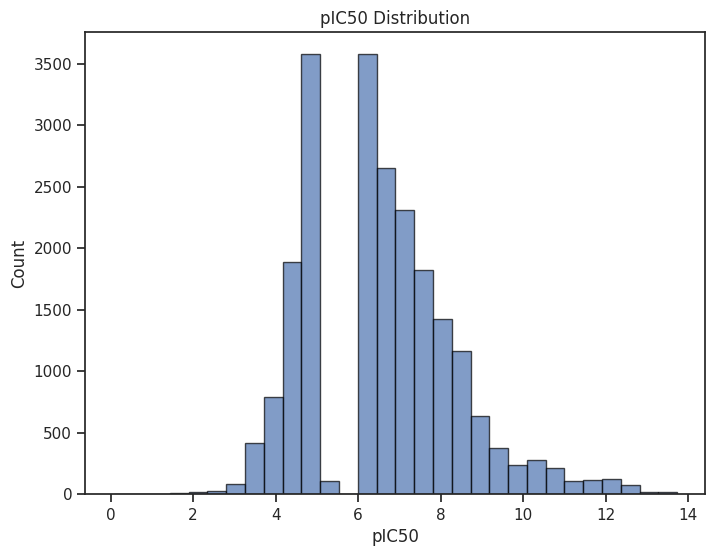

In [50]:
# 1. Remove non-finite values (inf and NaN)
df_clean_plot = df_clean[np.isfinite(df_clean["pIC50"])]

# 2. Plot the histogram
plt.figure(figsize=(8, 6))
plt.hist(df_clean_plot["pIC50"], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("pIC50 Distribution")

# 3. Save BEFORE showing
# Note: plt.show() clears the canvas, so savefig must come first
plt.savefig('histogram_pic50.pdf')
plt.show()

Text(0, 0.5, 'Frequency')

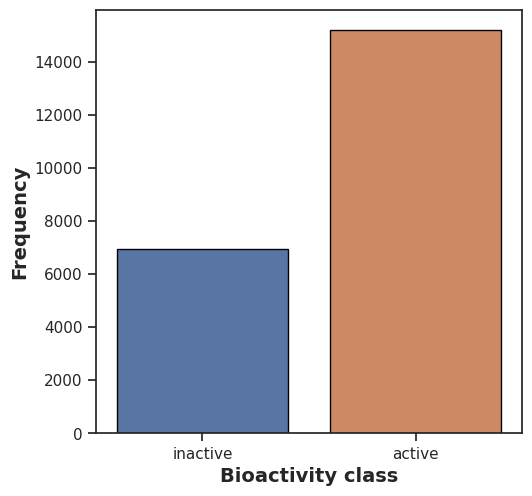

In [51]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="bioactivity_class", data= df_clean, hue="bioactivity_class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

**DESCRIPTORS**